In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [3]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0, notch_freq=50.0, Q=30.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        notch_b, notch_a = signal.iirnotch(notch_freq / nyquist, Q)
        filtered_signal = signal.filtfilt(b, a, signal_data, axis=axis)
        filtered_signal = signal.filtfilt(notch_b, notch_a, filtered_signal, axis=axis)
        return filtered_signal

In [4]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [5]:
path_load = './data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)
X_train = filter_signal(X_train, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)
X_test = filter_signal(X_test, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)
X_val = filter_signal(X_val, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| z_train   | (17418, 23)       |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| z_test    | (2198, 23)        |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+
| z_val     | (2183, 23)        |
+-----------+-------------------+


In [6]:
def detect_r_peaks(ecg_, fs):
    """
    Simple R-peak detector using diff, squaring, moving window integration, and adaptive thresholding.
    Returns: indices of detected R-peaks.
    """
    def simple_diff(signal):
        diff = []
        for i in range(1, len(signal)):
            diff.append(signal[i] - signal[i-1])
        return np.array(diff)

    diff = simple_diff(ecg_)
    diff = np.append(diff, 0)  # Append zero to match original length

    # Step 2: Squaring
    squared = diff ** 2

    # Step 3: Moving window integration
    window_size = int(0.150 * fs)  # 150 ms window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode='same')

    # Step 4: Simple adaptive thresholding and refractory period
    threshold = np.mean(integrated) * 1.5
    refractory_period = int(0.10 * fs)  # 250 ms

    peaks = []
    last_peak = -refractory_period

    for i in range(1, len(integrated) - 1):
        if integrated[i] > threshold and integrated[i] > integrated[i - 1] and integrated[i] > integrated[i + 1]:
            if i - last_peak > refractory_period:
                # Local search in raw signal for actual peak in a small window
                window = ecg_[i-10:i+10]
                if len(window) == 20:
                    true_peak = i - 10 + np.argmax(window)
                    peaks.append(true_peak)
                    last_peak = true_peak
    return np.array(peaks), integrated, squared, diff

def plot_r_peak_detection(t, ecg_, peaks, squared, integrated):
    """
    Plot ECG signal, detected R-peaks, squared signal, and integrated signal.
    """
    plt.figure(figsize=(12, 4))
    plt.plot(t, ecg_, label="ECG Signal")
    plt.plot(t[peaks], ecg_[peaks], 'ro', label="Detected R-peaks")
    plt.plot(t, squared, label="Squared Signal", alpha=0.6)
    plt.plot(t, integrated, label="Integrated Signal", alpha=0.6)
    plt.title("Self-implemented R-Peak Detector")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

In [7]:
ecg_ = X_train[10, :, 1]

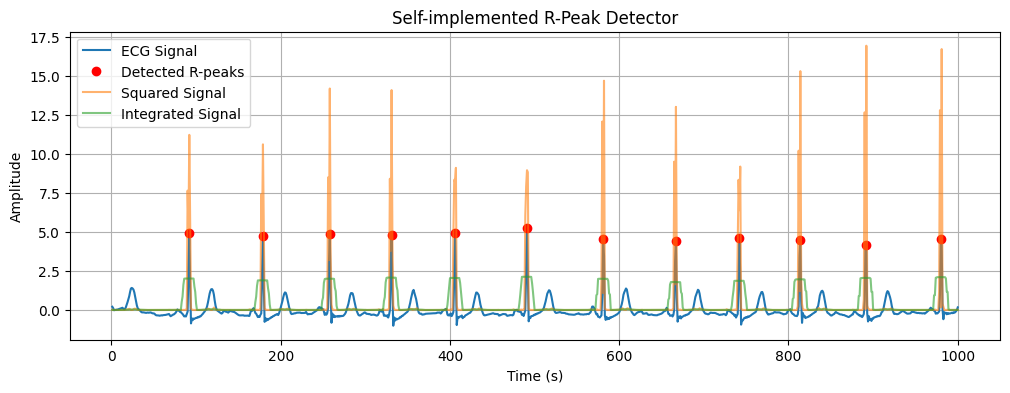

In [8]:
fs = 100
t = np.arange(1, len(ecg_) + 1)  # t ranges from 1 to 1000
r_peaks, integrated, squared, _ = detect_r_peaks(ecg_, fs)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_, label="ECG Signal")
plt.plot(t[r_peaks], ecg_[r_peaks], 'ro', label="Detected R-peaks")
plt.plot(t, squared, label="Squared Signal", alpha=0.6)
plt.plot(t, integrated, label="Integrated Signal", alpha=0.6)
plt.title("Self-implemented R-Peak Detector")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

In [9]:
def segment_PQRST(ecg, r_peaks, start_idx = 40, end_idx = 180):
    length = 1000
    PQRSTs = []
    expected_segment_length = 250
    for i, r_peak in enumerate(r_peaks):
        start_beat = np.max([0, r_peak - start_idx])
        end_beat =  np.min([r_peak + end_idx, length])
        segment = ecg[0, start_beat:end_beat]
        if expected_segment_length > end_beat - start_beat:
            padding = np.zeros(expected_segment_length - end_beat + start_beat)  # Create padding
            segment = np.concatenate((segment, padding))  # Pad the segment
        plt.figure()
        plt.plot(segment)
        PQRSTs.append(segment)
    return PQRSTs

<Figure size 1200x400 with 0 Axes>

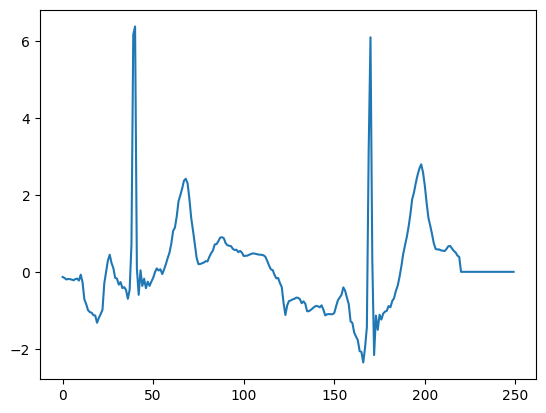

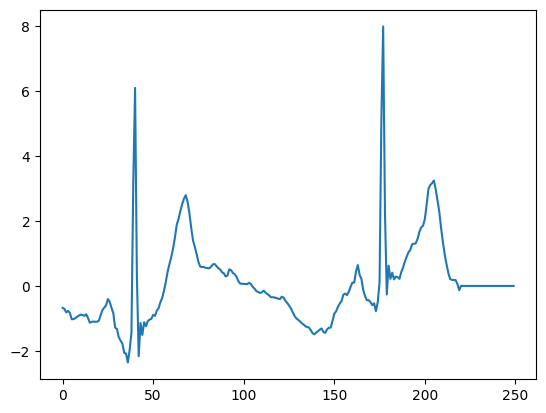

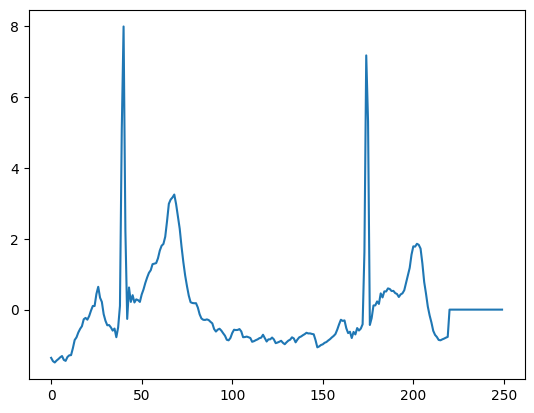

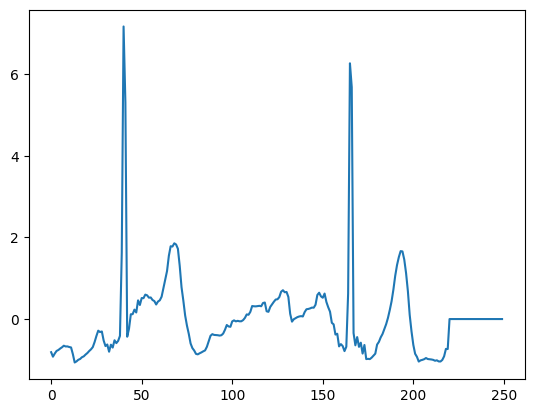

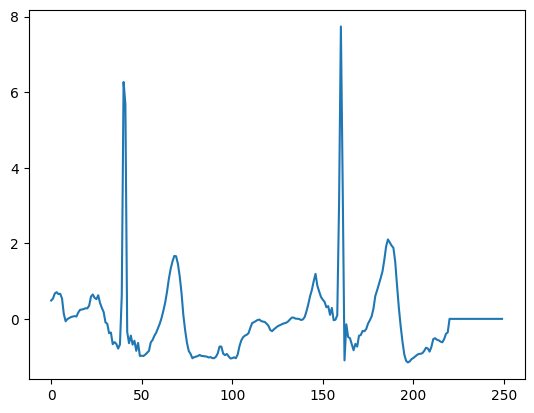

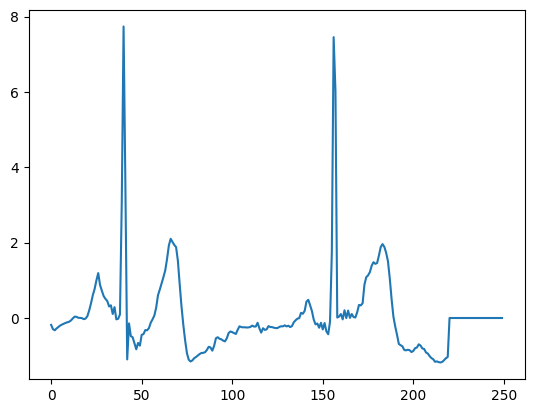

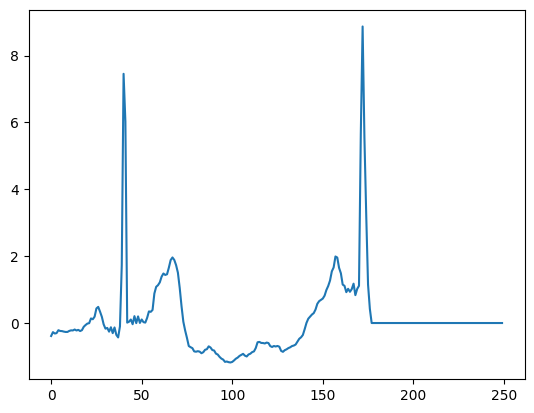

In [10]:
ecg = X_train[1, :, 1]
r_peaks, integrated, squared, _ = detect_r_peaks(ecg, fs)
plt.figure(figsize=(12, 4))
ecg = ecg.reshape(1, -1)
_ = segment_PQRST(ecg, r_peaks)
# ecg = ecg.reshape(-1)
# t = np.arange(1, len(ecg) + 1)  # t ranges from 1 to 1000
# print(t.shape)
# print(ecg.shape)
# plt.plot(t, ecg, label="ECG Signal")
# plt.plot(t[r_peaks], ecg[r_peaks], 'ro', label="Detected R-peaks")
# plt.plot(t, squared, label="Squared Signal", alpha=0.6)
# plt.plot(t, integrated, label="Integrated Signal", alpha=0.6)
# plt.title("Self-implemented R-Peak Detector")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
# plt.legend()
# plt.grid()
# plt.show()

In [11]:
def segment_PQRST(ecg, r_peaks, start_idx=40, end_idx=150):
    # The shape of ecg is (1, 1000, 12), so length is 1000 and number of channels is 12
    length = 1000
    PQRSTs = []
    expected_segment_length = 250
    
    # Iterate through each lead (channel) first
    for lead_idx in range(ecg.shape[2]):  # Loop through each lead (channel)
        segments_for_this_lead = []
        plt.figure()
        # Iterate through each R-peak and extract segments for this lead
        for i, r_peak in enumerate(r_peaks):
            start_beat = np.max([0, r_peak - start_idx])
            end_beat = np.min([r_peak + end_idx, length])
            if end_beat == length:
                continue
            # Check if we need padding at the start of the segment (if r_peak - start_idx is negative)
            if r_peak - start_idx < 0:
                start_padding = np.zeros(abs(r_peak - start_idx))  # Create padding at the start
                segment = ecg[0, start_beat:end_beat, lead_idx]  # Extract the segment
                segment = np.concatenate((start_padding, segment))  # Add start padding
            else:
                # Extract the segment without start padding if no negative index
                segment = ecg[0, start_beat:end_beat, lead_idx]
            
            # Pad the segment if it's shorter than the expected segment length at the end
            if expected_segment_length > len(segment):
                padding = np.zeros(expected_segment_length - len(segment))  # Create padding
                segment = np.concatenate((segment, padding))  # Pad the segment

            # Make sure the segment has the expected length
            assert len(segment) == expected_segment_length, f"Segment length mismatch: {len(segment)} != {expected_segment_length}"

            segments_for_this_lead.append(segment)
            
            # Plotting the segment for this lead (optional)
            plt.plot(segment)
        plt.title(f"Lead {lead_idx+1}, R-peak {i+1}")
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid()
        plt.show()
        
        # Add the segments for this lead (as a 2D array)
        PQRSTs.append(np.array(segments_for_this_lead))
    
    return PQRSTs

In [12]:
indices = np.where(y_train[:, 1] == 1.0)[0]
random_index = np.random.choice(indices)
ran= [random_index, random_index+1]
print(random_index)
print(ran)

9924
[np.int64(9924), np.int64(9925)]


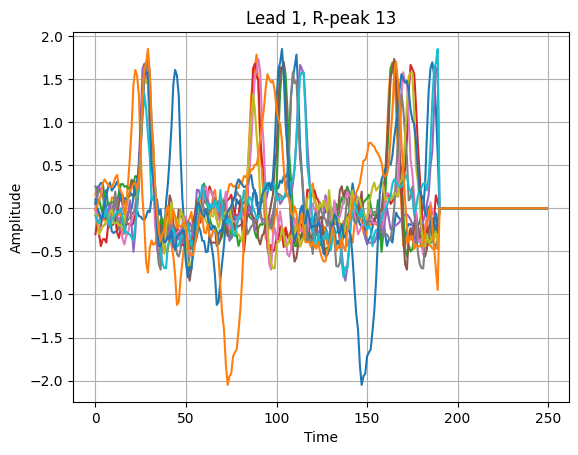

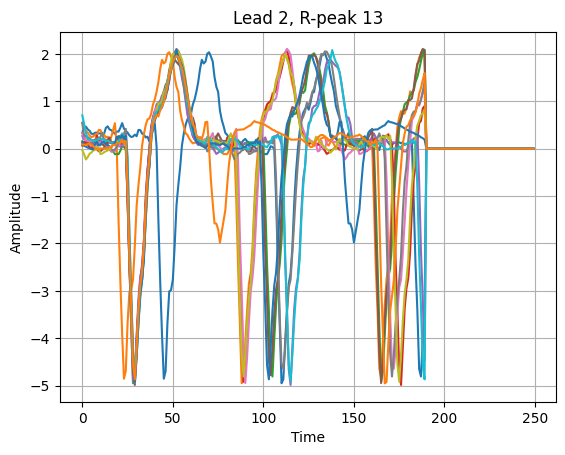

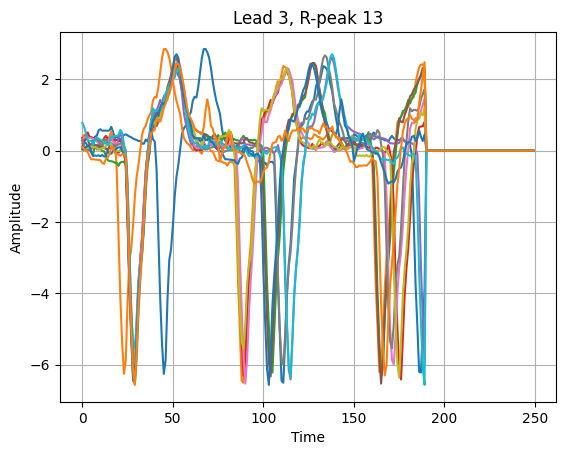

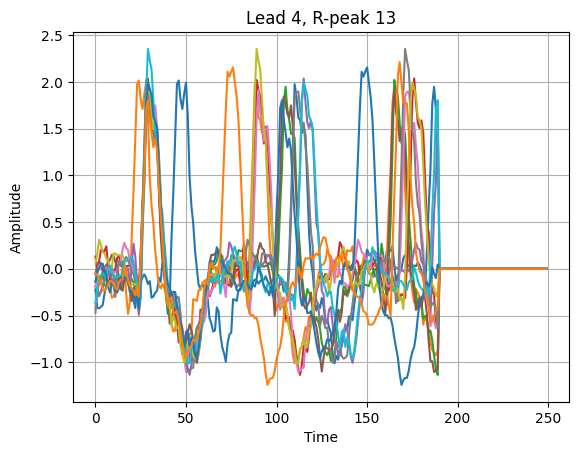

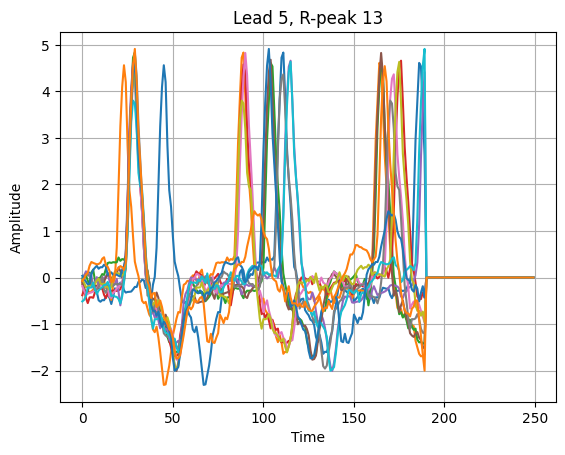

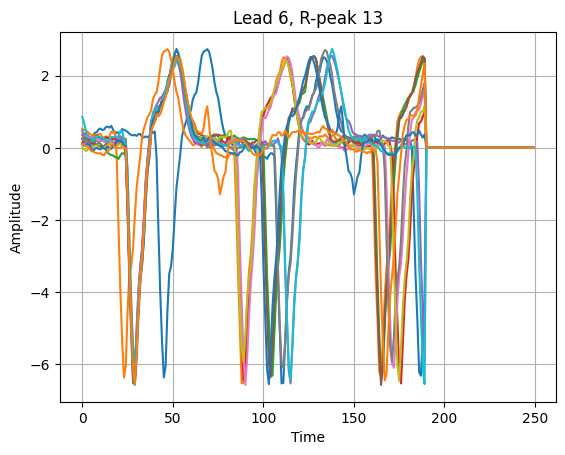

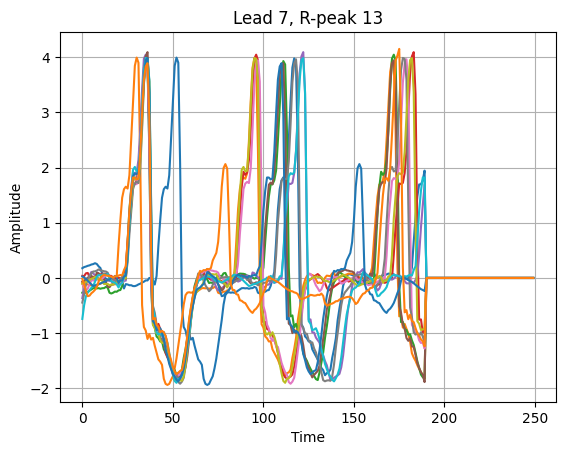

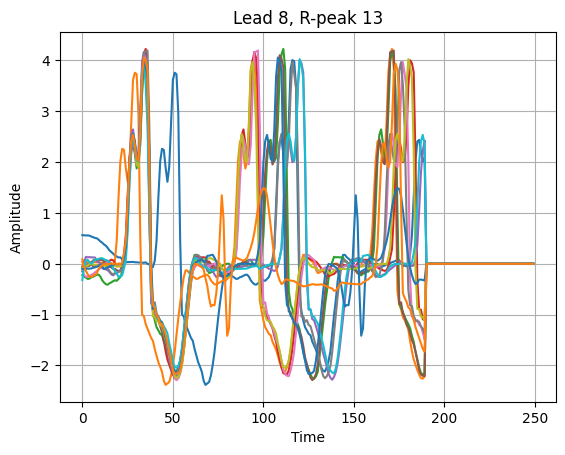

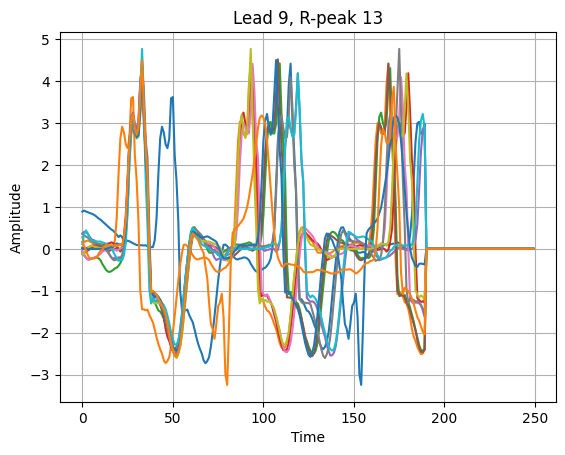

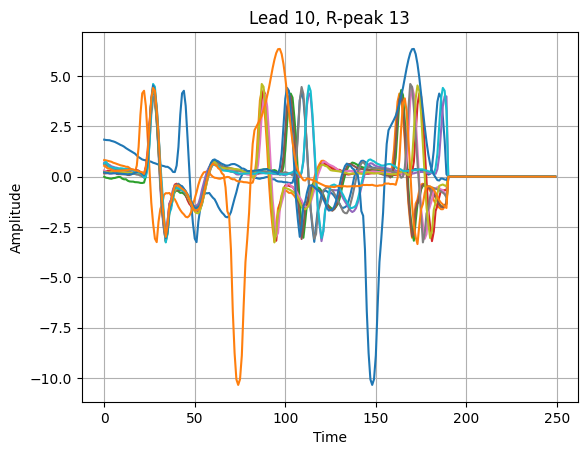

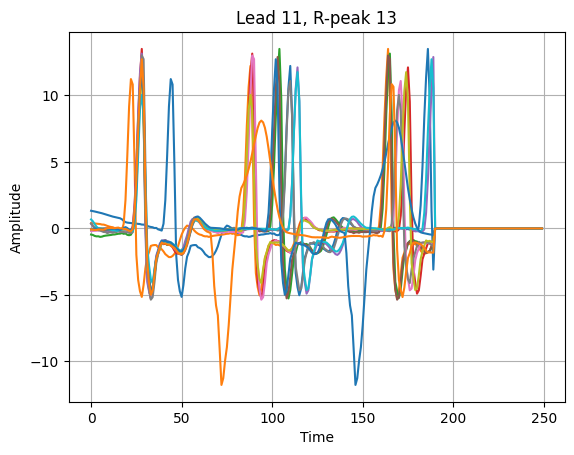

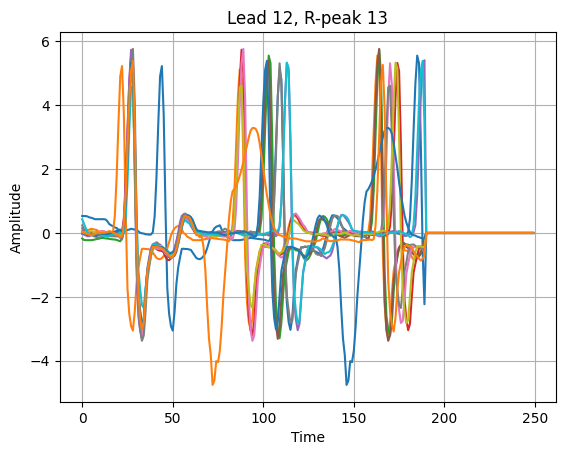

In [13]:
ecg = X_train[ran, :, :]
ecg_leadII = ecg[0, :, 1]
r_peaks, integrated, squared, _ = detect_r_peaks(ecg_leadII, fs)
PQRST_segment = segment_PQRST(ecg, r_peaks)

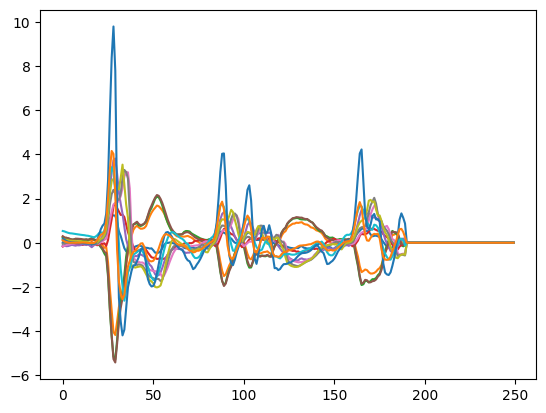

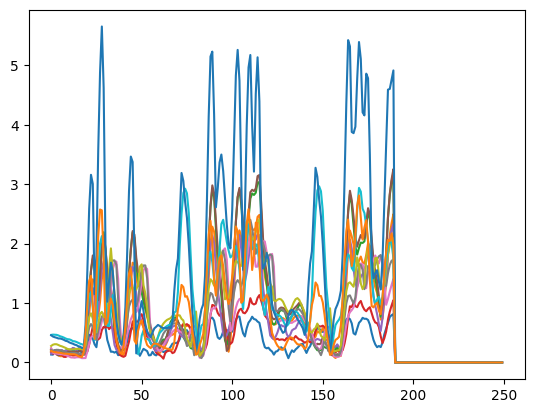

In [14]:
import numpy as np

def compute_mean_std(PQRSTs):
    # Convert PQRSTs into a NumPy array (12 leads, 4 R-peaks, 250 samples per segment)
    PQRSTs = np.array(PQRSTs)  # Shape: (12, 4, 250)
    
    # Compute mean and std for each lead across R-peaks (axis 1) while preserving the time axis (axis 2)
    means = np.mean(PQRSTs, axis=1, keepdims=True)  # Mean across R-peaks (12, 1, 250)
    stds = np.std(PQRSTs, axis=1, keepdims=True)    # Std across R-peaks (12, 1, 250)
    
    return means, stds

# Example usage:
means, stds = compute_mean_std(PQRST_segment)

# Print the results for each lead (shape: (12, 1, 250))
for lead_idx in range(12):
    plt.plot(means[lead_idx][0])
plt.figure()
for lead_idx in range(12):
    plt.plot(stds[lead_idx][0])

In [15]:
def detect_r_peaks(ecg_, fs):
    """
    Simple R-peak detector using diff, squaring, moving window integration, and adaptive thresholding.
    Returns: indices of detected R-peaks.
    """
    def simple_diff(signal):
        diff = []
        for i in range(1, len(signal)):
            diff.append(signal[i] - signal[i-1])
        return np.array(diff)

    diff = simple_diff(ecg_)
    diff = np.append(diff, 0)  # Append zero to match original length

    # Step 2: Squaring
    squared = diff ** 2

    # Step 3: Moving window integration
    window_size = int(0.150 * fs)  # 150 ms window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode='same')

    # Step 4: Simple adaptive thresholding and refractory period
    threshold = np.mean(integrated) * 1.5
    refractory_period = int(0.10 * fs)  # 250 ms

    peaks = []
    last_peak = -refractory_period

    for i in range(1, len(integrated) - 1):
        if integrated[i] > threshold and integrated[i] > integrated[i - 1] and integrated[i] > integrated[i + 1]:
            if i - last_peak > refractory_period:
                # Local search in raw signal for actual peak in a small window
                window = ecg_[i-10:i+10]
                if len(window) == 20:
                    true_peak = i - 10 + np.argmax(window)
                    peaks.append(true_peak)
                    last_peak = true_peak
    return np.array(peaks), integrated, squared, diff

def segment_PQRST(ecg, r_peaks, start_idx=40, end_idx=150):
    # The shape of ecg is (1, 1000, 12), so length is 1000 and number of channels is 12
    length = 1000
    PQRSTs = []
    expected_segment_length = 250
    
    # Iterate through each lead (channel) first
    for lead_idx in range(ecg.shape[2]):  # Loop through each lead (channel)
        segments_for_this_lead = []
        #plt.figure()
        # Iterate through each R-peak and extract segments for this lead
        for i, r_peak in enumerate(r_peaks):
            start_beat = np.max([0, r_peak - start_idx])
            end_beat = np.min([r_peak + end_idx, length])
            if end_beat == length:
                continue
            # Check if we need padding at the start of the segment (if r_peak - start_idx is negative)
            if r_peak - start_idx < 0:
                start_padding = np.zeros(abs(r_peak - start_idx))  # Create padding at the start
                segment = ecg[0, start_beat:end_beat, lead_idx]  # Extract the segment
                segment = np.concatenate((start_padding, segment))  # Add start padding
            else:
                # Extract the segment without start padding if no negative index
                segment = ecg[0, start_beat:end_beat, lead_idx]
            
            # Pad the segment if it's shorter than the expected segment length at the end
            if expected_segment_length > len(segment):
                padding = np.zeros(expected_segment_length - len(segment))  # Create padding
                segment = np.concatenate((segment, padding))  # Pad the segment

            # Make sure the segment has the expected length
            assert len(segment) == expected_segment_length, f"Segment length mismatch: {len(segment)} != {expected_segment_length}"

            segments_for_this_lead.append(segment)
            
            # Plotting the segment for this lead (optional)
            #plt.plot(segment)
        # plt.title(f"Lead {lead_idx+1}, R-peak {i+1}")
        # plt.xlabel('Time')
        # plt.ylabel('Amplitude')
        # plt.grid()
        # plt.show()
        
        # Add the segments for this lead (as a 2D array)
        PQRSTs.append(np.array(segments_for_this_lead))
    
    return PQRSTs

def compute_mean_std(PQRSTs):
    # Convert PQRSTs into a NumPy array (12 leads, 4 R-peaks, 250 samples per segment)
    PQRSTs = np.array(PQRSTs)  # Shape: (12, 4, 250)
    
    # Compute mean and std for each lead across R-peaks (axis 1) while preserving the time axis (axis 2)
    means = np.mean(PQRSTs, axis=1, keepdims=True)  # Mean across R-peaks (12, 1, 250)
    stds = np.std(PQRSTs, axis=1, keepdims=True)    # Std across R-peaks (12, 1, 250)
    
    return means, stds

[1. 0. 0. 0. 0.]


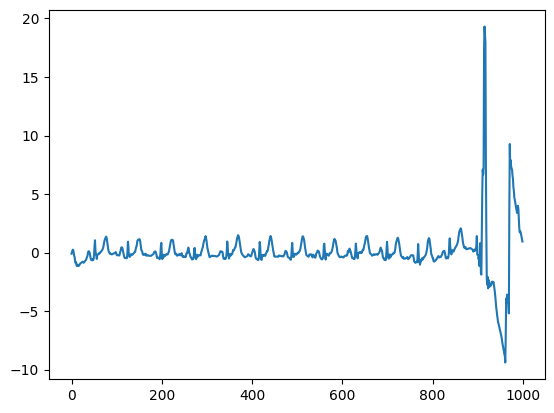

In [16]:
plt.plot(X_train[12927, :, 1])
print(y_train[12927])

In [19]:
def extract_mean_stds(dataset, fs = 100):
    all_means = []
    all_stds = []
    for i in range(dataset.shape[0]):
        # Select a random sample (replace 'ran' with a valid index or variable)
        ecg = dataset[i, :, :]
        ecg = np.expand_dims(ecg, axis = 0)
        # Assuming you're extracting Lead II for R-peaks detection
        ecg_leadII = ecg[0, :, 1]
    
        # Detect R-peaks
        r_peaks, _, _, _ = detect_r_peaks(ecg_leadII, fs)
    
        # Segment the PQRST segments
        PQRST_segment = segment_PQRST(ecg, r_peaks)
    
        # Compute mean and std for the segmented PQRSTs
        means, stds = compute_mean_std(PQRST_segment)
    
        if means.shape == (12, 1, 250):
            # Reshape if necessary, but keep them in the correct shape (1, 250, 12)
            means = means.reshape(1, 250, 12)  # Reshape means to (1, 250, 12)
            stds = stds.reshape(1, 250, 12)    # Reshape stds to (1, 250, 12)
        else:
            print(f"Index {i} has no means, stds")
            means = np.zeros((1, 250, 12))
            stds = np.zeros((1, 250, 12))  
        # Append the results for each sample
        all_means.append(means)
        all_stds.append(stds)

    # Convert lists to arrays at the end
    all_means = np.concatenate(all_means, axis=0)  # Shape will be (B, 250, 12) where B is the number of samples
    all_stds = np.concatenate(all_stds, axis=0)    # Shape will be (B, 250, 12)

    # Check the shape of the final arrays
    print("Means shape:", all_means.shape)  # Expected shape: (B, 250, 12)
    print("Stds shape:", all_stds.shape)    # Expected shape: (B, 250, 12)
    return all_means, all_stds

In [22]:
import os
path = "./data_source_sub/"
means, stds = extract_mean_stds(X_val,fs=100)
np.save(os.path.join(path, "M_val.npy"), means)
np.save(os.path.join(path, "S_val.npy"), stds)

/home/alex/dev/ecg-signal-processing/repo/ecg-ptb-xl/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/alex/dev/ecg-signal-processing/repo/ecg-ptb-xl/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/alex/dev/ecg-signal-processing/repo/ecg-ptb-xl/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alex/dev/ecg-signal-processing/repo/ecg-ptb-xl/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/alex/dev/ecg-signal-processing/repo/ecg-ptb-xl/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value e

Index 1065 has no means, stds
Means shape: (2183, 250, 12)
Stds shape: (2183, 250, 12)
